In [17]:
import pandas as pd
from glob import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Multiple performance records

In [2]:
fpaths_performance_records= glob(os.path.join('data', 'performanceRecords*.json')) 
print(len(fpaths_performance_records))

450


In [3]:
def load_performance_record(fpath: str) -> pd.DataFrame:
    """ Load a performance record.
    Returns a DataFrame.

    ----
    Performance Record (05/01/2025)
    { 
        records: [],
        nRecords: int,
        experimentTag: str,
        batchTimestamp: int,
        iteration: int
    }
    
    """
    df_i = pd.read_json(fpath)
    df_i_a = df_i.merge(df_i.records.apply(pd.Series),left_index=True,right_index=True)
    df_i_b = df_i_a.merge(
        df_i_a.detail.apply(pd.Series),
        left_index=True, right_index=True
    )
    df_i_c = df_i_b.drop(['records','detail'],axis=1)
    return df_i_c
    
    
dfs = []
for i,fpath in enumerate(sorted(fpaths_performance_records)):
    dfs.append(load_performance_record(fpath))
    

In [4]:
def preprocess_dfc(dfc: pd.DataFrame) -> pd.DataFrame:
    dfc = dfc.drop(['entryType', 'duration'], axis=1)
    dfc['step'] = dfc['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
    dfc['stepType'] = dfc['name'].apply(lambda x: x.split('_')[0])
    dfc = dfc.drop(['name'],axis=1)
    return dfc

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [5]:
# create dfc
dfc = pd.concat(
    (load_performance_record(fpath) for fpath in fpaths_performance_records),
    axis = 0
)
# preprocess
dfc = preprocess_dfc(dfc)
display(dfc.head())
print(dfc.shape)

,nRecords,experimentTag,iteration,batchTimestamp,startTime,implementation,step,stepType
0,4,ed25519-signature-2023-141,141,1736044095,89270.280833,Ed25519Signature2020,SIGN_VC,START
1,4,ed25519-signature-2023-141,141,1736044095,89271.248708,Ed25519Signature2020,SIGN_VC,END
2,4,ed25519-signature-2023-141,141,1736044095,89271.317375,Ed25519Signature2020,VERIFY_VC,START
3,4,ed25519-signature-2023-141,141,1736044095,89272.166625,Ed25519Signature2020,VERIFY_VC,END
0,4,ed25519-signature-2023-59,59,1736044095,88990.944041,Ed25519Signature2020,SIGN_VC,START


(3000, 8)


In [6]:
dfc.sort_values(['experimentTag','iteration'])

,nRecords,experimentTag,iteration,batchTimestamp,startTime,implementation,step,stepType
0,8,bbs-bls-signature-2020-0,0,1736044095,68344.986125,BbsBlsSignature2020,SIGN_VC,START
1,8,bbs-bls-signature-2020-0,0,1736044095,68385.202625,BbsBlsSignature2020,SIGN_VC,END
2,8,bbs-bls-signature-2020-0,0,1736044095,68385.218125,BbsBlsSignature2020,VERIFY_VC,START
3,8,bbs-bls-signature-2020-0,0,1736044095,68423.464666,BbsBlsSignature2020,VERIFY_VC,END
4,8,bbs-bls-signature-2020-0,0,1736044095,68423.803750,BbsBlsSignature2020,DERIVE,START
...,...,...,...,...,...,...,...,...
3,4,ed25519-signature-2023-98,98,1736044095,89131.248958,Ed25519Signature2020,VERIFY_VC,END
0,4,ed25519-signature-2023-99,99,1736044095,89132.744166,Ed25519Signature2020,SIGN_VC,START
1,4,ed25519-signature-2023-99,99,1736044095,89133.940333,Ed25519Signature2020,SIGN_VC,END
2,4,ed25519-signature-2023-99,99,1736044095,89134.031250,Ed25519Signature2020,VERIFY_VC,START


In [7]:
dfc.groupby(['implementation', 'iteration']).size()

implementation               iteration
BbsBlsSignature2020          0            8
                             1            8
                             2            8
                             3            8
                             4            8
                                         ..
bbs-termwise-signature-2023  145          8
                             146          8
                             147          8
                             148          8
                             149          8
Length: 450, dtype: int64

`dfc_x`

In [8]:
dfc_x = dfc.set_index(['implementation', 'iteration','step','stepType'])
dfc_x.head()

nRecords  \
implementation       iteration step      stepType             
Ed25519Signature2020 141       SIGN_VC   START            4   
                                         END              4   
                               VERIFY_VC START            4   
                                         END              4   
                     59        SIGN_VC   START            4   

                                                                experimentTag  \
implementation       iteration step      stepType                               
Ed25519Signature2020 141       SIGN_VC   START     ed25519-signature-2023-141   
                                         END       ed25519-signature-2023-141   
                               VERIFY_VC START     ed25519-signature-2023-141   
                                         END       ed25519-signature-2023-141   
                     59        SIGN_VC   START      ed25519-signature-2023-59   

                                                   batchTimestamp  \
implementation       iteration step      stepType                   
Ed25519Signature2020 141       SIGN_VC   START         1736044095   
                                         END           1736044095   
                               VERIFY_VC START         1736044095   
                                         END           1736044095   
                     59        SIGN_VC   START         1736044095   

                                                      startTime  
implementation       iteration step      stepType                
Ed25519Signature2020 141       SIGN_VC   START     89270.280833  
                                         END       89271.248708  
                               VERIFY_VC START     89271.317375  
                                         END       89272.166625  
                     59        SIGN_VC   START     88990.944041

----

`a`: the DataFrame containing the preprocessed performance records.

In [10]:
# Unstack: turn START and END to columns
a = dfc_x['startTime'].unstack('stepType')
# Compute delta time
a['delta'] = a.apply(lambda r: r.END - r.START, axis=1)
# Now, START and END columns are no longer needed.
a.drop(['START','END'], axis=1, inplace=True)
a

stepType                                                   delta
implementation              iteration step                      
BbsBlsSignature2020         0         DERIVE           63.286500
                                      SIGN_VC          40.216500
                                      VERIFY_DERIVED   32.719459
                                      VERIFY_VC        38.246541
                            1         DERIVE           56.065875
...                                                          ...
bbs-termwise-signature-2023 148       VERIFY_VC        80.369125
                            149       DERIVE          198.061292
                                      SIGN_VC          69.505208
                                      VERIFY_DERIVED   94.072583
                                      VERIFY_VC        80.698417

[1500 rows x 1 columns]

`b`: the DataFrame containing descriptive statistics from the performance records in DataFrame `a`.

In [11]:
b = a.copy()
b.reset_index(inplace=True)
b = b.groupby(['implementation','step'])['delta'].agg(['mean','std', 'var','min','max','count'])
b

mean        std         var  \
implementation              step                                                
BbsBlsSignature2020         DERIVE           54.661687   2.965119    8.791929   
                            SIGN_VC          16.382181   2.203996    4.857599   
                            VERIFY_DERIVED   29.453559   1.095703    1.200565   
                            VERIFY_VC        31.449785   4.748971   22.552729   
Ed25519Signature2020        SIGN_VC           1.349724   1.304361    1.701358   
                            VERIFY_VC         1.153692   0.734837    0.539985   
bbs-termwise-signature-2023 DERIVE          201.989756  10.161053  103.246999   
                            SIGN_VC          71.279646  10.326422  106.634988   
                            VERIFY_DERIVED   94.996348   4.167531   17.368311   
                            VERIFY_VC        82.266309   8.379096   70.209255   

                                                   min         max  count  
implementation              step                                           
BbsBlsSignature2020         DERIVE           50.962750   73.844500    150  
                            SIGN_VC          15.124292   40.216500    150  
                            VERIFY_DERIVED   27.981625   34.217083    150  
                            VERIFY_VC        29.700041   78.105583    150  
Ed25519Signature2020        SIGN_VC           0.888458   14.123209    150  
                            VERIFY_VC         0.761166    6.950333    150  
bbs-termwise-signature-2023 DERIVE          194.836417  276.039292    150  
                            SIGN_VC          67.145584  189.383958    150  
                            VERIFY_DERIVED   92.593875  131.344167    150  
                            VERIFY_VC        78.543958  168.535250    150

`c`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [13]:
c = b.copy()
c = c['mean'].unstack('step').T
c

implementation,BbsBlsSignature2020,Ed25519Signature2020,bbs-termwise-signature-2023
step,,,
DERIVE,54.661687,NaN,201.989756
SIGN_VC,16.382181,1.349724,71.279646
VERIFY_DERIVED,29.453559,NaN,94.996348
VERIFY_VC,31.449785,1.153692,82.266309


Seaborn

In [43]:
# df seaborn
dfsb = a.reset_index()
#display(dfsb.head())


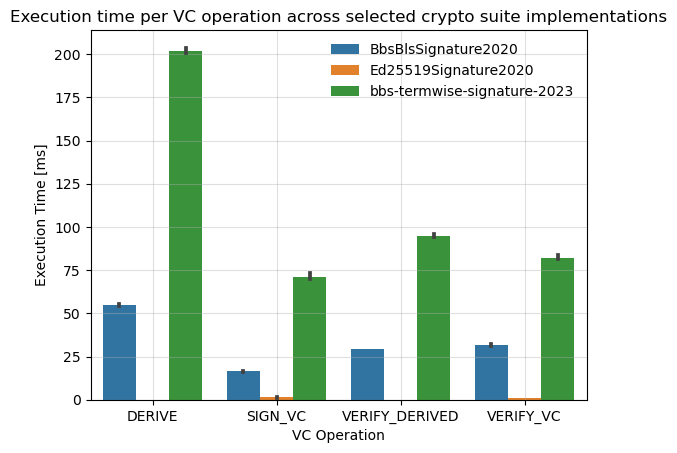

In [42]:
ax = sns.barplot(
    data = dfsb,
    x = 'step',
    hue = 'implementation',
    y = 'delta')

ax.legend(frameon=False)
ax.set_title('Execution time per VC operation across selected crypto suite implementations')
ax.set_xlabel('VC Operation')
ax.set_ylabel('Execution Time [ms]')
ax.grid(alpha=.4)
plt.show()

# ⚠️⬇︎TO REVISE

----

---

In [35]:
dfc_x = dfc.set_index(['implementation', 'step','stepType'])
dfc_x.drop(['name'], axis=1, inplace=True)
print('dfc_x')
dfc_x

dfc_x


startTime  \
implementation              step           stepType                  
BbsBlsSignature2020         SIGN_VC        START     231670.211041   
                                           END       231688.029166   
                            VERIFY_VC      START     231688.037625   
                                           END       231718.637375   
                            DERIVE         START     231718.814041   
...                                                            ...   
bbs-termwise-signature-2023 VERIFY_VC      END       230460.815833   
                            DERIVE         START     230460.881083   
                                           END       230660.464958   
                            VERIFY_DERIVED START     230660.922791   
                                           END       230757.697666   

                                                               fname  
implementation              step           stepType                   
BbsBlsSignature2020         SIGN_VC        START     1735950612.json  
                                           END       1735950612.json  
                            VERIFY_VC      START     1735950612.json  
                                           END       1735950612.json  
                            DERIVE         START     1735950612.json  
...                                                              ...  
bbs-termwise-signature-2023 VERIFY_VC      END       1735950611.json  
                            DERIVE         START     1735950611.json  
                                           END       1735950611.json  
                            VERIFY_DERIVED START     1735950611.json  
                                           END       1735950611.json  

[2417 rows x 2 columns]

In [36]:
dfc_x['jaja'] = dfc.groupby(['implementation',]).cumcount().values

In [37]:
dfc_x

startTime  \
implementation              step           stepType                  
BbsBlsSignature2020         SIGN_VC        START     231670.211041   
                                           END       231688.029166   
                            VERIFY_VC      START     231688.037625   
                                           END       231718.637375   
                            DERIVE         START     231718.814041   
...                                                            ...   
bbs-termwise-signature-2023 VERIFY_VC      END       230460.815833   
                            DERIVE         START     230460.881083   
                                           END       230660.464958   
                            VERIFY_DERIVED START     230660.922791   
                                           END       230757.697666   

                                                               fname  jaja  
implementation              step           stepType                         
BbsBlsSignature2020         SIGN_VC        START     1735950612.json     0  
                                           END       1735950612.json     1  
                            VERIFY_VC      START     1735950612.json     2  
                                           END       1735950612.json     3  
                            DERIVE         START     1735950612.json     4  
...                                                              ...   ...  
bbs-termwise-signature-2023 VERIFY_VC      END       1735950611.json  1584  
                            DERIVE         START     1735950611.json  1585  
                                           END       1735950611.json  1586  
                            VERIFY_DERIVED START     1735950611.json  1587  
                                           END       1735950611.json  1588  

[2417 rows x 3 columns]

In [38]:
dfc_x = dfc.set_index(['implementation', 'step','stepType', 'fname'])
dfc_x.drop(['name'], axis=1, inplace=True)
print('dfc_x')
dfc_x

dfc_x


startTime
implementation              step           stepType fname                         
BbsBlsSignature2020         SIGN_VC        START    1735950612.json  231670.211041
                                           END      1735950612.json  231688.029166
                            VERIFY_VC      START    1735950612.json  231688.037625
                                           END      1735950612.json  231718.637375
                            DERIVE         START    1735950612.json  231718.814041
...                                                                            ...
bbs-termwise-signature-2023 VERIFY_VC      END      1735950611.json  230460.815833
                            DERIVE         START    1735950611.json  230460.881083
                                           END      1735950611.json  230660.464958
                            VERIFY_DERIVED START    1735950611.json  230660.922791
                                           END      1735950611.json  230757.697666

[2417 rows x 1 columns]

In [39]:

dfc_x = dfc_x.unstack('stepType').droplevel(0, axis=1)
dfc_x['duration'] = dfc_x.END - dfc_x.START
display(dfc_x)
#dfc_x.diff(axis=1).dropna(how='all',axis=1).


stepType                                                         END  \
implementation              step      fname                            
BbsBlsSignature2020         DERIVE    1735950612.json  231771.000583   
                                      1735950613.json  232864.095791   
                                      1735950614.json  233791.870291   
                                      1735950615.json  234880.028375   
                                      1735950616.json  235768.504833   
...                                                              ...   
bbs-termwise-signature-2023 VERIFY_VC 1735950607.json  226473.174875   
                                      1735950608.json  227356.498666   
                                      1735950609.json  228239.580708   
                                      1735950610.json  229566.575250   
                                      1735950611.json  230460.815833   

stepType                                                       START  \
implementation              step      fname                            
BbsBlsSignature2020         DERIVE    1735950612.json  231718.814041   
                                      1735950613.json  232812.688791   
                                      1735950614.json  233739.503916   
                                      1735950615.json  234828.734708   
                                      1735950616.json  235714.777166   
...                                                              ...   
bbs-termwise-signature-2023 VERIFY_VC 1735950607.json  226393.917958   
                                      1735950608.json  227275.564625   
                                      1735950609.json  228160.065416   
                                      1735950610.json  229485.231958   
                                      1735950611.json  230381.615000   

stepType                                                duration  
implementation              step      fname                       
BbsBlsSignature2020         DERIVE    1735950612.json  52.186542  
                                      1735950613.json  51.407000  
                                      1735950614.json  52.366375  
                                      1735950615.json  51.293667  
                                      1735950616.json  53.727667  
...                                                          ...  
bbs-termwise-signature-2023 VERIFY_VC 1735950607.json  79.256917  
                                      1735950608.json  80.934041  
                                      1735950609.json  79.515292  
                                      1735950610.json  81.343292  
                                      1735950611.json  79.200833  

[1322 rows x 3 columns]

---

In [48]:
A = dfc_x.reset_index().groupby(['implementation','step'])['duration'].agg(['mean','std', 'size'])
A

mean       std  size
implementation              step                                      
BbsBlsSignature2020         DERIVE           52.500577  1.501562    69
                            SIGN_VC          15.803298  0.716380    69
                            VERIFY_DERIVED   28.767950  0.867453    69
                            VERIFY_VC        30.119100  1.073151    69
Ed25519Signature2020        SIGN_VC           1.272083  0.291782    69
                            VERIFY_VC         1.219056  0.659544    69
bbs-termwise-signature-2023 DERIVE          203.056301  9.614101   227
                            SIGN_VC                NaN       NaN   227
                            VERIFY_DERIVED   95.476968  2.713683   227
                            VERIFY_VC        82.655184  4.613800   227

In [56]:
A.reset_index().set_index(['implementation','step'])

mean       std  size
implementation              step                                      
BbsBlsSignature2020         DERIVE           52.500577  1.501562    69
                            SIGN_VC          15.803298  0.716380    69
                            VERIFY_DERIVED   28.767950  0.867453    69
                            VERIFY_VC        30.119100  1.073151    69
Ed25519Signature2020        SIGN_VC           1.272083  0.291782    69
                            VERIFY_VC         1.219056  0.659544    69
bbs-termwise-signature-2023 DERIVE          203.056301  9.614101   227
                            SIGN_VC                NaN       NaN   227
                            VERIFY_DERIVED   95.476968  2.713683   227
                            VERIFY_VC        82.655184  4.613800   227

----

----

----

----

----

---
# TO REVISE

In [8]:
df = pd.read_json('performanceRecords.json')

In [9]:
df

,name,entryType,startTime,duration,detail
0,START_SIGN_VC,mark,611.853416,0,{'implementation': 'BbsBlsSignature2020'}
1,END_SIGN_VC,mark,651.437583,0,{'implementation': 'BbsBlsSignature2020'}
2,START_VERIFY_VC,mark,651.454125,0,{'implementation': 'BbsBlsSignature2020'}
3,END_VERIFY_VC,mark,690.556500,0,{'implementation': 'BbsBlsSignature2020'}
4,START_DERIVE,mark,690.837041,0,{'implementation': 'BbsBlsSignature2020'}
5,END_DERIVE,mark,754.739750,0,{'implementation': 'BbsBlsSignature2020'}
6,START_VERIFY_DERIVED,mark,754.994666,0,{'implementation': 'BbsBlsSignature2020'}
7,END_VERIFY_DERIVED,mark,787.943666,0,{'implementation': 'BbsBlsSignature2020'}


In [10]:


df = df.drop(['detail','entryType','duration'], axis=1).merge(df.detail.apply(pd.Series), left_index=True, right_index=True)
df['step'] = df['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
df['stepType'] = df['name'].apply(lambda x: x.split('_')[0])
df.drop('name',axis=1,inplace=True)
df.set_index(['implementation', 'step','stepType'],inplace=True)
df.sort_index(inplace=True)
df

startTime
implementation      step           stepType            
BbsBlsSignature2020 DERIVE         END       754.739750
                                   START     690.837041
                    SIGN_VC        END       651.437583
                                   START     611.853416
                    VERIFY_DERIVED END       787.943666
                                   START     754.994666
                    VERIFY_VC      END       690.556500
                                   START     651.454125

In [5]:
df2 = df.unstack('stepType')['startTime']
df2

stepType                                   END       START
implementation      step                                  
BbsBlsSignature2020 DERIVE          754.739750  690.837041
                    SIGN_VC         651.437583  611.853416
                    VERIFY_DERIVED  787.943666  754.994666
                    VERIFY_VC       690.556500  651.454125

In [6]:
df2_diff = df2.END - df2.START
df2_diff = df2_diff.unstack('implementation')
df2_diff.round(2)

implementation,BbsBlsSignature2020
step,
DERIVE,63.90
SIGN_VC,39.58
VERIFY_DERIVED,32.95
VERIFY_VC,39.10
